**Block 1: Introduction and Imports**

In [1]:
##   Project: Action Recognition using CNN + LSTM (UCF50 - 18 classes)
##  Goal: Classify videos based on actions using deep learning (TimeDistributed CNN + LSTM)

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras.optimizers import Adam

2026-06-20 03:31:31.037844: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781926291.462706      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781926291.593066      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781926292.555192      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781926292.555267      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781926292.555269      58 computation_placer.cc:177] computation placer alr

**Block 2: Define Classes and Paths****

In [2]:
# Define the 18 selected action classes
selected_classes = [
    "Basketball",
    "Diving",
    "HorseRace",
    "JumpRope",
    "VolleyballSpiking",
    "WalkingWithDog",
    "BenchPress",
    "Biking",
    "GolfSwing",
    "HighJump",
    "Kayaking",
    "PullUps",
    "PushUps",
    "RopeClimbing",
    "SkateBoarding",
    "SoccerJuggling",
    "Swing",
    "TrampolineJumping"
]
# UCF50 dataset path
dataset_path ="/kaggle/input/datasets/pypiahmad/realistic-action-recognition-ucf50/UCF50"

# Confirm folder structure
for cls in selected_classes:
    print(f"{cls} → Total videos:", len(os.listdir(os.path.join(dataset_path, cls))))

Basketball → Total videos: 137
Diving → Total videos: 153
HorseRace → Total videos: 127
JumpRope → Total videos: 148
VolleyballSpiking → Total videos: 116
WalkingWithDog → Total videos: 123
BenchPress → Total videos: 160
Biking → Total videos: 145
GolfSwing → Total videos: 142
HighJump → Total videos: 123
Kayaking → Total videos: 157
PullUps → Total videos: 120
PushUps → Total videos: 106
RopeClimbing → Total videos: 130
SkateBoarding → Total videos: 120
SoccerJuggling → Total videos: 156
Swing → Total videos: 137
TrampolineJumping → Total videos: 119


**Block 3: EDA – Show Sample Frames from Each Class**

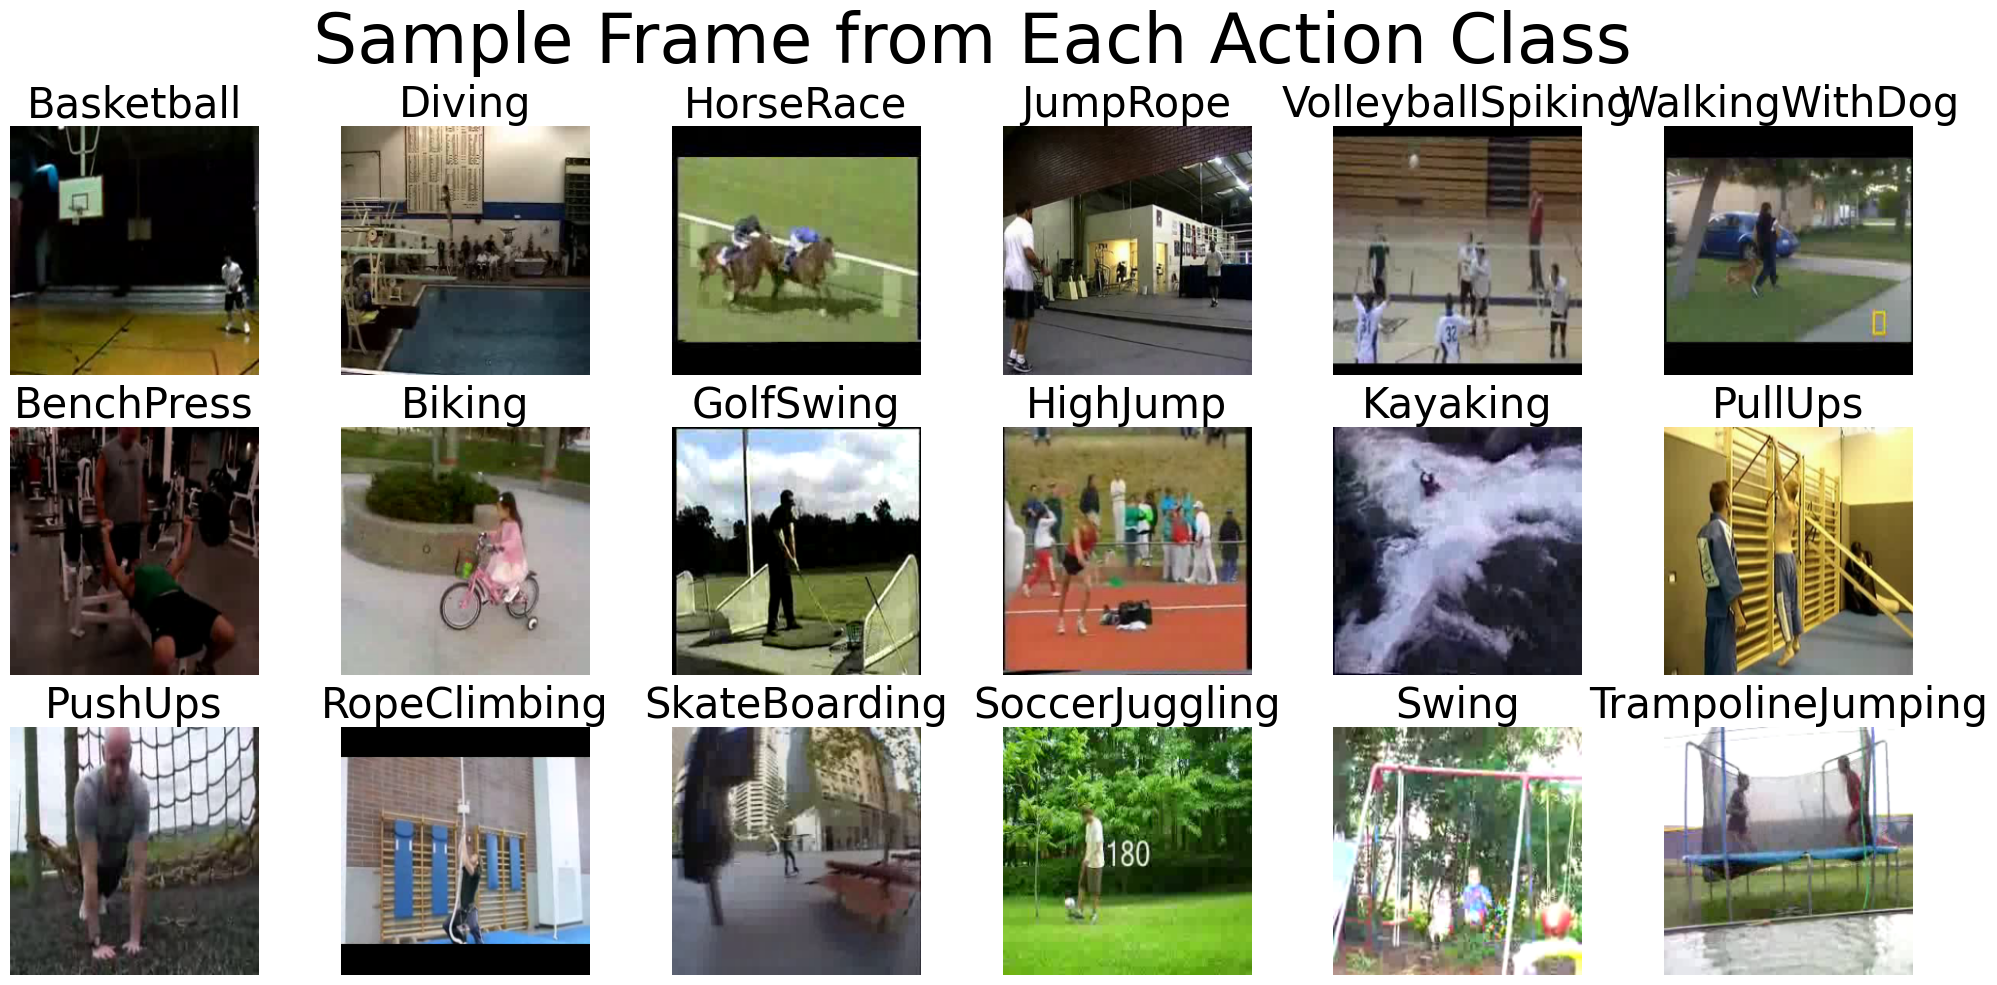

In [3]:
# Show 1 frame from 1 video of each class

def show_sample_frames(classes, dataset_path):
    fig, axes = plt.subplots(3, 6, figsize=(20, 10))  # 3 rows and 6 columns
    axes = axes.flatten()  # make it easy to loop over

    for i, cls in enumerate(classes):
        # Load first video from the class folder
        video_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])
        cap = cv2.VideoCapture(video_path) #think of cap like a video player that's paused and ready to play frame by frame.

        # ret: a boolean (True/False) — it’s True if a frame was read successfully
        # frame: the actual image/frame (as a NumPy array)
        ret, frame = cap.read()
        cap.release() # This closes the video file after you're done

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (256, 256))
            axes[i].imshow(frame)
            axes[i].set_title(cls , fontsize = 30)
        axes[i].axis('off')    

    plt.suptitle(" Sample Frame from Each Action Class", fontsize=50)
    plt.tight_layout()
    plt.show()

# Calling
show_sample_frames(selected_classes, dataset_path)

**Block 4: Extract Frames from Videos**

In [4]:
#  Extract fixed number of frames from each video
# For simplicity and speed, we’ll extract 20 frames per video

def extract_frames(video_path, num_frames=20):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(total_frames // num_frames, 1)
    
    count = 0
    while len(frames) < num_frames and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame = cv2.resize(frame, (64, 64))
            frame = frame / 255.0  # Normalize pixel values
            frames.append(frame)
        count += 1
    cap.release()

    # Pad with last frame if video too short
    while len(frames) < num_frames:
        frames.append(frames[-1])
    
    return np.array(frames)

**Block 5: Load Videos and Create Dataset**

In [5]:
# Loop through videos in selected classes and extract frames
X = []
y = []

for class_index, cls in enumerate(selected_classes):
    class_path = os.path.join(dataset_path, cls)
    videos = os.listdir(class_path)  

    for video in videos:
        video_path = os.path.join(class_path, video)
        frames = extract_frames(video_path, num_frames=20)
        if frames.shape == (20, 64, 64, 3):  # Ensure consistent shape
            X.append(frames)
            y.append(class_index)

X = np.array(X)
y = to_categorical(y) # One-Hot

print(" Data Loaded:")
print("X shape:", X.shape)  # (samples, time_steps, height, width, channels)
print("y shape:", y.shape)  # (samples, num_classes)

 Data Loaded:
X shape: (2419, 20, 64, 64, 3)
y shape: (2419, 18)


**Block 6: Train-Test Split**

In [6]:
#  Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training videos:", X_train.shape[0])
print("Testing videos:", X_test.shape[0])

Training videos: 1935
Testing videos: 484


**Block 7: Build CNN + LSTM Model with TimeDistributed**

In [7]:
#  Model = CNN applied on each frame using TimeDistributed + LSTM for sequence learning

model = Sequential()
model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'), input_shape=(20, 64, 64, 3)))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Flatten()))

# LSTM layer for temporal patterns
model.add(LSTM(64))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(18, activation='softmax'))  # 18 classes

# Compile model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

#CNNs process one image at a time.

#TimeDistributed allows us to apply the same CNN to each frame in a video — one by one — automatically. 

# CNNs: Take each frame of video and say "Ah! I see a net, a ball, a hand…"

# LSTM: Looks at how these elements move across frames and says "This looks like basketball!"

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-06-20 03:39:37.016869: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


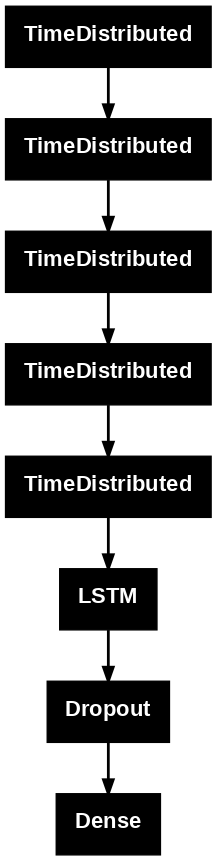

In [8]:
plot_model(model,dpi=100)

**Block 8: Train the Model**

In [9]:
#  Train the model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=4)

Epoch 1/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 342s 694ms/step - accuracy: 0.2269 - loss: 2.5481 - val_accuracy: 0.3843 - val_loss: 2.0916
Epoch 2/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 371s 766ms/step - accuracy: 0.4532 - loss: 1.8609 - val_accuracy: 0.5041 - val_loss: 1.6302
Epoch 3/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 348s 719ms/step - accuracy: 0.5855 - loss: 1.4184 - val_accuracy: 0.6467 - val_loss: 1.2006
Epoch 4/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 313s 647ms/step - accuracy: 0.7018 - loss: 1.0436 - val_accuracy: 0.7087 - val_loss: 0.9894
Epoch 5/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 313s 647ms/step - accuracy: 0.7685 - loss: 0.7949 - val_accuracy: 0.7355 - val_loss: 0.8380
Epoch 6/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 315s 650ms/step - accuracy: 0.8517 - loss: 0.5555 - val_accuracy: 0.7955 - val_loss: 0.7034
Epoch 7/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 311s 642ms/step - accuracy: 0.9039 - loss: 0.3967 - val_accuracy: 0.7893 - val_loss: 0.6966
Epoch 8/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 323s 667ms/step - accuracy: 0.9354 -

**Block 9: Plot Accuracy and Loss**

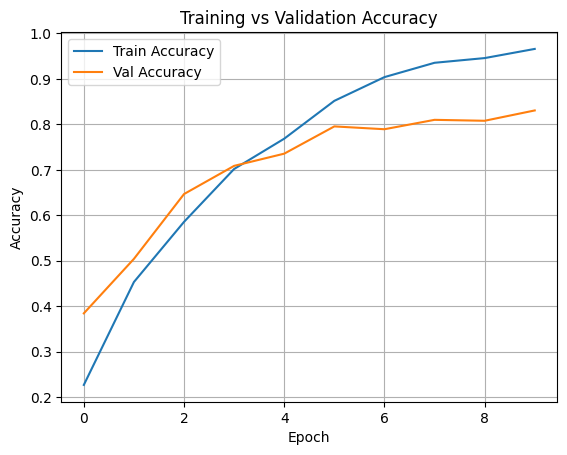

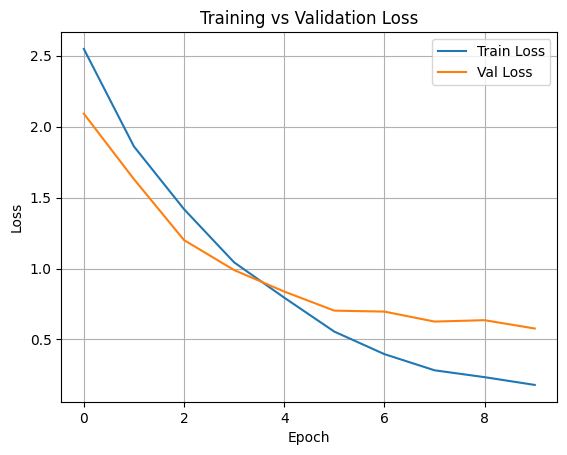

In [10]:
#  Training vs Validation Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#  Training vs Validation Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Block 10: Show Model Predictions on 5 Random Test Videos**

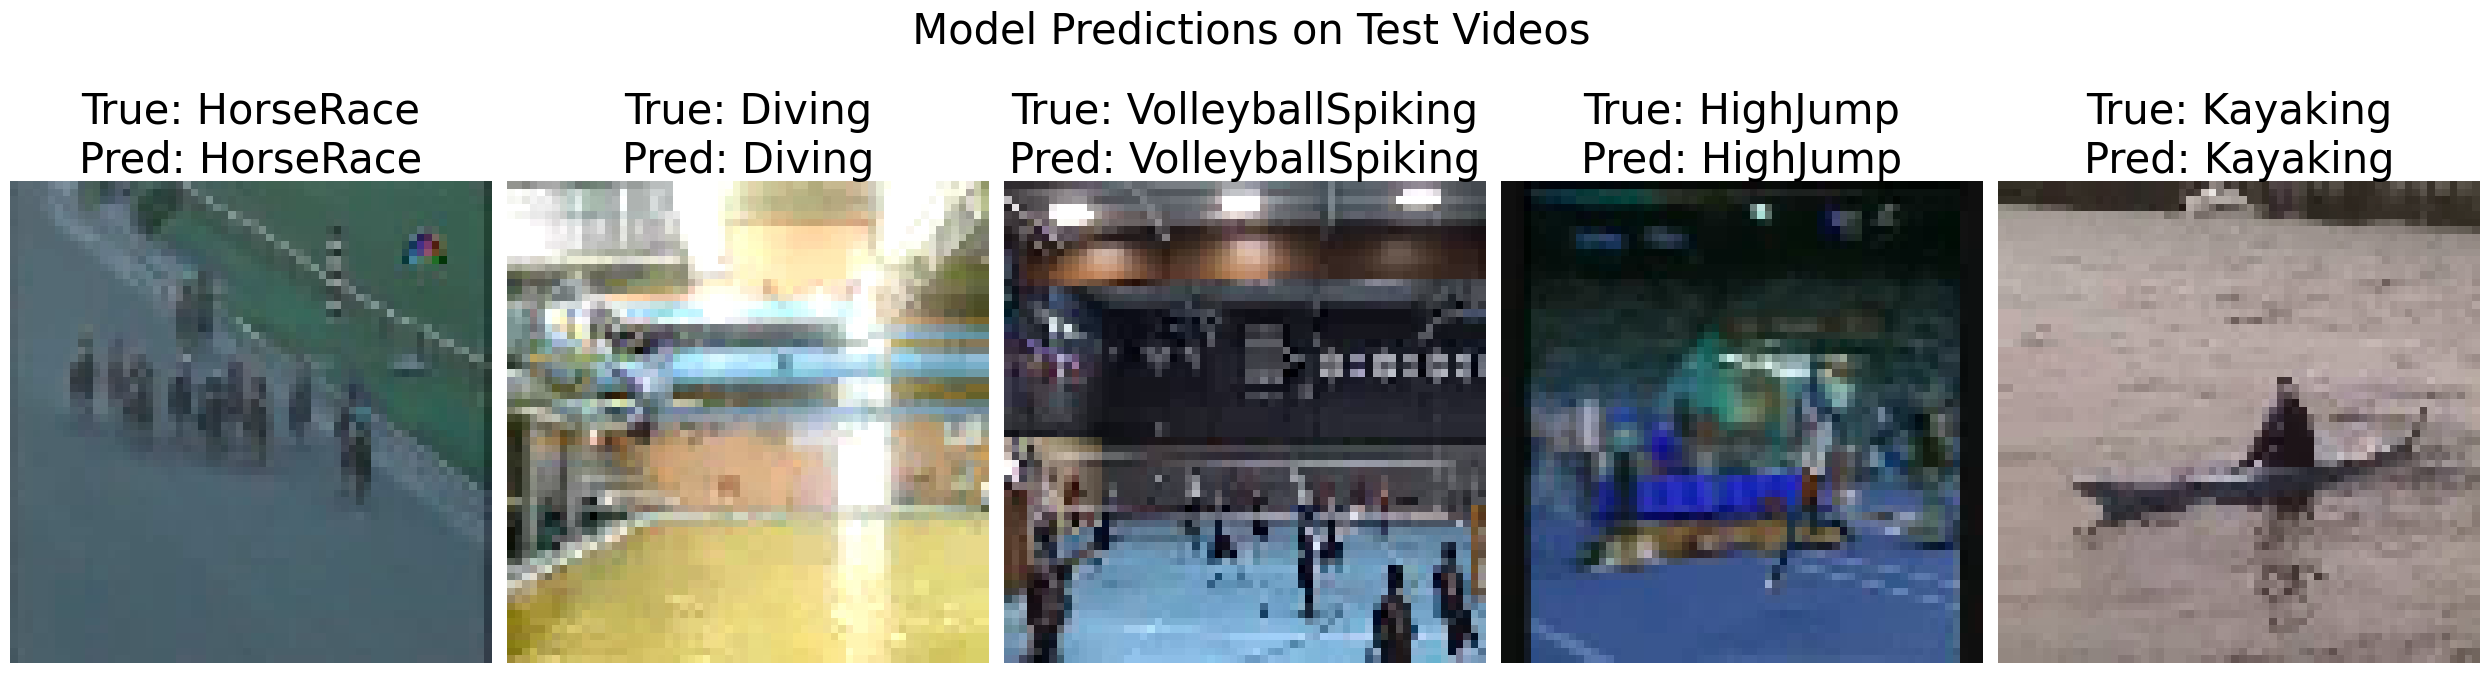

In [11]:
#  Visualize model predictions on 5 test videos (larger images)
def show_predictions(model, X_test, y_test, class_names):
    # Get 5 random indices
    indices = np.random.choice(len(X_test), 5, replace=False)
    
    # Bigger canvas size
    fig, axes = plt.subplots(1, 5, figsize=(25, 8))  #  Wider and taller

    for i, idx in enumerate(indices):
        video = X_test[idx]
        true_label = class_names[np.argmax(y_test[idx])]

        # Predict
        prediction = model.predict(np.expand_dims(video, axis=0), verbose=0)
        predicted_label = class_names[np.argmax(prediction)]

        # Get middle frame and denormalize
        mid_frame = video[len(video) // 2]
        mid_frame = (mid_frame * 255).astype(np.uint8)

        # Optional: remove resizing if frame is already big enough
        # frame = cv2.resize(mid_frame, (256, 256))  # or skip this
        frame = mid_frame  # Show full original frame size

        # Plot
        axes[i].imshow(frame)
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}", fontsize=30)
        axes[i].axis('off')

    plt.suptitle(" Model Predictions on Test Videos", fontsize=30)
    plt.tight_layout()
    plt.show()

#  Run it
show_predictions(model, X_test, y_test, selected_classes)

**Block 11: Final Notes**

In [12]:
print("1- We built an action recognition model using CNN + LSTM (TimeDistributed)")
print("2- CNN: Extracted spatial features from each frame")
print("3- LSTM: Learned sequence of actions over time")
print("4- Only 18 classes used to keep it simple")

1- We built an action recognition model using CNN + LSTM (TimeDistributed)
2- CNN: Extracted spatial features from each frame
3- LSTM: Learned sequence of actions over time
4- Only 18 classes used to keep it simple
